<a href="https://colab.research.google.com/github/sarika178btcse25-netizen/ML-and-GenAI-with-Python-2026/blob/main/HomeWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# STEP 1: IMPORT LIBRARIES

# Pandas is used for reading and manipulating datasets
import pandas as pd

# NumPy helps with numerical computations
import numpy as np

# Machine Learning Algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

# Used to split dataset into training and testing data
from sklearn.model_selection import train_test_split

# Used to evaluate classification models
from sklearn.metrics import accuracy_score, confusion_matrix

# Used to encode categorical values
from sklearn.preprocessing import LabelEncoder
# STEP 2: LOAD DATASET

# STEP 2: LOAD DATASET
# STEP 2: LOAD DATASET

df = pd.read_csv('Dataset 2.csv')

# Display first 5 rows
df.head()


,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


In [17]:
# Assuming your dataset is loaded into a DataFrame named 'df'
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 750
Number of columns: 10


In [18]:
print(df.columns)

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')


In [5]:
print(df.dtypes)

UserID                  int64
Age                     int64
Gender                 object
SubscriptionType       object
WatchHoursPerWeek       int64
DevicesUsed             int64
FavoriteGenre          object
AdClicks                int64
MonthlySpend            int64
SubscriptionRenewed    object
dtype: object


In [6]:


# Identify numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Identify categorical features
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']
Categorical Features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


In [7]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


In [8]:
average_age = df['Age'].mean()
print(f"The average age of Netflix users in this dataset is: {average_age:.2f} years")

The average age of Netflix users in this dataset is: 41.82 years


In [9]:
average_watchhourperweek = df['WatchHoursPerWeek'].mean()
print(f"The average age of Netflix users in this dataset is: {average_watchhourperweek:.2f} years")



The average age of Netflix users in this dataset is: 14.24 years


In [10]:
average_monthly_spend = df['MonthlySpend'].mean()
print(f"The average monthly spending of users is: ${average_monthly_spend:.2f}")

The average monthly spending of users is: $689.91


In [11]:
# Assuming your dataset is loaded into a DataFrame named 'df'
# Q9. Count the number of users in each subscription category

subscription_counts = df['SubscriptionType'].value_counts()

# Display the result
print("Number of users in each subscription category:")
print(subscription_counts)

Number of users in each subscription category:
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


In [12]:
# Assuming your pandas DataFrame is named 'df'
# and the target column is 'Subscription Renewed'

# Calculate the percentage of users who renewed
renewal_percentage = (df['SubscriptionRenewed'].value_counts(normalize=True) * 100).get('Yes', 0)

print(f"Percentage of users who renewed their subscriptions: {renewal_percentage:.2f}%")

Percentage of users who renewed their subscriptions: 46.27%


In [19]:
import pandas as pd

# 1. Map binary target and ordinal subscription categories
df['SubscriptionRenewed'] = df['SubscriptionRenewed'].map({'Yes': 1, 'No': 0})
df['SubscriptionType'] = df['SubscriptionType'].map({'Basic': 0, 'Premium': 1, 'VIP': 2})

# 2. One-hot encode the remaining nominal categories
df = pd.get_dummies(df, columns=['Gender', 'FavoriteGenre'], drop_first=True)

# 3. Display the updated columns to verify conversion
print(df.head())

   UserID  Age  SubscriptionType  WatchHoursPerWeek  DevicesUsed  AdClicks  \
0    1001   22                 0                 23            5        13   
1    1002   55                 0                  9            4        14   
2    1003   49                 0                  8            3        16   
3    1004   39                 1                 19            5        45   
4    1005   38                 1                 23            5        24   

   MonthlySpend  SubscriptionRenewed  Gender_Male  FavoriteGenre_Comedy  \
0           353                    0        False                  True   
1           317                    1         True                 False   
2           309                    0         True                  True   
3           833                    1        False                 False   
4           804                    1        False                 False   

   FavoriteGenre_Drama  FavoriteGenre_Horror  FavoriteGenre_Romance  \
0        

In [22]:
# Assuming your DataFrame is named 'df' after running the Q11 encoding step

# 1. Define the target variable (y)
y = df['SubscriptionRenewed']

# 2. Define the feature set (X)
# We drop the target column and the unique identifier 'UserID'
X = df.drop(columns=['SubscriptionRenewed', 'UserID'])

# 3. Verify the shapes to make sure everything lines up
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (750, 12)
Target shape (y): (750,)


In [23]:
from sklearn.model_selection import train_test_split

# Assuming X and y have already been defined from Q12
# We use test_size=0.2 for an 80/20 split and set a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the proportions of the split
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (600, 12)
Testing features shape: (150, 12)
Training target shape: (600,)
Testing target shape: (150,)


In [24]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree Classifier
# Setting random_state=42 ensures the results are reproducible
dt_model = DecisionTreeClassifier(random_state=42)

# 2. Train (fit) the model using the training data
dt_model.fit(X_train, y_train)

print("Decision Tree model has been successfully trained!")

Decision Tree model has been successfully trained!


In [25]:
from sklearn.metrics import accuracy_score

# 1. Use the trained Decision Tree model to make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# 2. Calculate the accuracy score by comparing actual labels (y_test) with predicted labels (y_pred_dt)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# 3. Display the accuracy as a percentage
print(f"Decision Tree Model Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Model Accuracy: 52.67%


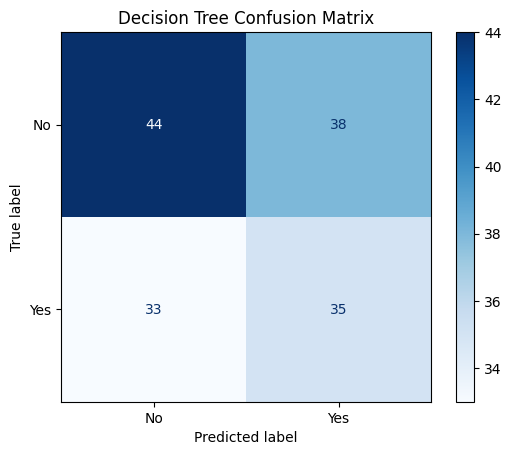

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the confusion matrix array
# y_test: actual target values, y_pred_dt: predictions made by Decision Tree in Q15
cm = confusion_matrix(y_test, y_pred_dt)

# 2. Display and visualize the confusion matrix
# Assuming 0 = 'No' (Did not renew) and 1 = 'Yes' (Renewed)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap=plt.cm.Blues)

# 3. Save or show the plot
plt.title("Decision Tree Confusion Matrix")
plt.savefig("confusion_matrix.png")

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize the KNN Classifier with K = 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train (fit) the KNN model using your training data split from Q13
knn_model.fit(X_train, y_train)

print("KNN Classifier (K=5) has been successfully trained!")

KNN Classifier (K=5) has been successfully trained!


In [28]:
from sklearn.metrics import accuracy_score

# 1. Use the trained KNN model (from Q17) to make predictions on the test data
y_pred_knn = knn_model.predict(X_test)

# 2. Calculate the accuracy score for KNN
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# 3. Print a clean, formatted comparison of both models
print("=========================================")
print("       Model Accuracy Comparison         ")
print("=========================================")
print(f"Decision Tree Accuracy : {dt_accuracy * 100:.2f}%")
print(f"KNN Classifier (K=5)   : {knn_accuracy * 100:.2f}%")
print("=========================================")

# 4. Programmatically determine which model performed better
if dt_accuracy > knn_accuracy:
    print(f"Result: The Decision Tree outperformed KNN by {df_diff:+(dt_accuracy - knn_accuracy)*100:.2f}%.")
elif knn_accuracy > dt_accuracy:
    print(f"Result: KNN outperformed the Decision Tree by {(knn_accuracy - dt_accuracy)*100:.2f}%.")
else:
    print("Result: Both models achieved the exact same accuracy score.")

       Model Accuracy Comparison         
Decision Tree Accuracy : 52.67%
KNN Classifier (K=5)   : 63.33%
Result: KNN outperformed the Decision Tree by 10.67%.


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Assuming 'df' is your encoded DataFrame from Q11

# 1. Define the target variable (y) and feature set (X) for the regression task
y_reg = df['MonthlySpend']
X_reg = df.drop(columns=['MonthlySpend', 'UserID'])

# 2. Split the dataset into training and testing sets (80/20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Initialize the Linear Regression model
lr_model = LinearRegression()

# 4. Train (fit) the model on the regression training data
lr_model.fit(X_train_reg, y_train_reg)

print("Linear Regression model has been successfully trained!")

Linear Regression model has been successfully trained!


In [33]:
import pandas as pd

# 1. Define raw demographic and behavioral attributes for a new user
new_user_data = {
    'Age': [30],
    'Gender': ['Female'],
    'Subscription Type': ['Premium'],
    'WatchHours PerWeek': [18.5],
    'Devices Used': [3],
    'FavoriteGenre': ['Comedy'],
    'AdClicks': [4],
    'Subscription Renewed': [1] # Assuming 1 for 'Yes'
}

# Convert the dictionary into a pandas DataFrame
new_user_df = pd.DataFrame(new_user_data)

# 2. Apply the exact preprocessing/encoding mapping used in Q11
subscription_mapping = {'Basic': 0, 'Premium': 1, 'VIP': 2}
new_user_df['Subscription Type'] = new_user_df['Subscription Type'].map(subscription_mapping)

# Perform one-hot encoding for nominal categories
new_user_encoded = pd.get_dummies(new_user_df, columns=['Gender', 'FavoriteGenre'])

# 3. Align columns with the training feature set (X_reg from Q19)
# This fills missing columns with 0 if the new user doesn't belong to certain categories
new_user_final = new_user_encoded.reindex(columns=X_reg.columns, fill_value=0)

# 4. Use the trained Linear Regression model (lr_model) to predict
predicted_spend = lr_model.predict(new_user_final)[0]

print(f"Predicted Monthly Spend for the new user: ${predicted_spend:.2f}")

Predicted Monthly Spend for the new user: $274.73
